# Assignment 16

## PART 1 - Advanced Supervised Algorithms

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Read dataset 

data=pd.read_csv('student_dropout_dataset_v3.csv')

In [3]:
data.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

### Task 1: Support Vector Machine (SVM)


In [5]:
# 1. Select a Classification dataset

features= ['Age','Family_Income','Study_Hours_per_Day','Attendance_Rate','Assignment_Delay_Days','Travel_Time_Minutes','Stress_Index','GPA','Semester_GPA','CGPA']

X=data[features]
Y=data['Dropout']

In [6]:
## Missing Data Handling

X=X.fillna(X.median())

In [7]:
## Check missing value

X.isnull().sum()

Age                      0
Family_Income            0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
dtype: int64

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [9]:
# 2. Split into train and test sets

X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [10]:
# Standardization of data because SVM is sensitive to feature scale

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [11]:
# 3. Train an SVM classifier using SVC

svm_linear=SVC(kernel='linear',random_state=42)

svm_linear.fit(X_train_scaled,Y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [12]:
# 4. Experiment with linear kernel

y_pred_linear=svm_linear.predict(X_test_scaled)

In [13]:
linear_accuracy=accuracy_score(Y_test,y_pred_linear)

In [14]:
linear_accuracy

0.8075

In [15]:
# 4. Experiment with RBF kernel
svm_rbf=SVC(kernel='rbf',random_state=42)

svm_rbf.fit(X_train_scaled,Y_train)

y_pred_rbf=svm_rbf.predict(X_test_scaled)

rbf_accuracy=accuracy_score(Y_test,y_pred_rbf)

In [16]:
rbf_accuracy

0.8105

In [17]:
# 5. Compare accuracy of both kernels

print("Compare accuracy of both kernels ")
print("Linear Kernel", linear_accuracy)
print("RBF Kernel", rbf_accuracy)

Compare accuracy of both kernels 
Linear Kernel 0.8075
RBF Kernel 0.8105


## Task 2: Decision Tree Algorithm

In [18]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [19]:
# 1. Train a Decision Tree Classifier

dt_model=DecisionTreeClassifier(random_state=42)

In [20]:
dt_model.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
# make prediction

y_predict=dt_model.predict(X_test)

In [22]:
train_accuracy=accuracy_score(Y_train,dt_model.predict(X_train))

test_accuracy=accuracy_score(Y_test,y_predict)

In [23]:
print("Training Accuracy:",train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.7305


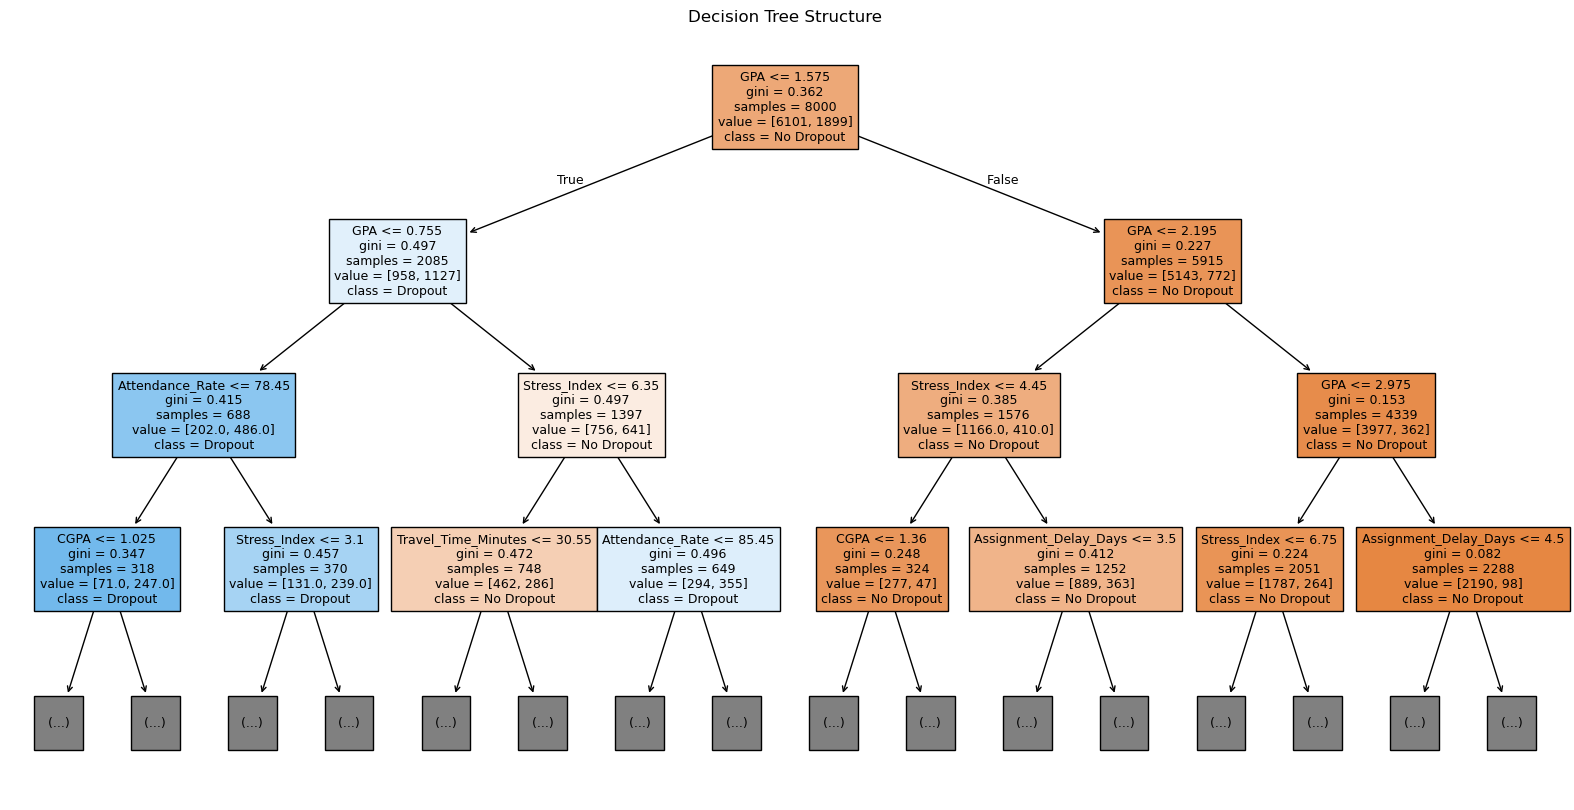

In [24]:
# 2. Visualize the tree structure (depth limited)

plt.figure(figsize=(20,10))

plot_tree(dt_model,
        feature_names=features,
        class_names=['No Dropout','Dropout'],
        filled=True,
        max_depth=3,
        fontsize=9
)
plt.title("Decision Tree Structure")
plt.show()

In [25]:
# 3. Train model with Low max_depth (Underfitting)

dt_low=DecisionTreeClassifier(max_depth=2, random_state=42)

dt_low.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
# Accuracy for low max_depth

low_train_accuracy=accuracy_score(Y_train,dt_low.predict(X_train))

low_test_accuracy=accuracy_score(Y_test,dt_low.predict(X_test))

print("Low Depth Decision Tree")
print("Training Accuracy:", low_train_accuracy)
print("Testing Accuracy:", low_test_accuracy)

Low Depth Decision Tree
Training Accuracy: 0.798125
Testing Accuracy: 0.802


In [27]:
# 3. Train model with high max_depth (Overfitting)

dt_high=DecisionTreeClassifier(max_depth=30, random_state=42)

dt_high.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
# Accuracy for high depth value

high_train_accuracy=accuracy_score(Y_train,dt_high.predict(X_train))

high_test_accuracy=accuracy_score(Y_test,dt_high.predict(X_test))

print("High Depth Decision Tree")
print("Training Accuracy:", high_train_accuracy)
print("Test Accuracy:", high_test_accuracy)

High Depth Decision Tree
Training Accuracy: 0.99875
Test Accuracy: 0.733


## PART 2 - Model Validation & Cross Validation

### Task 3 : Train vs Validation vs Test-Split

In [44]:
# 1. Split data into Training set, validation set , test set

# Separate 20% as test data

X_temp, X_test, Y_temp, Y_test=train_test_split(X,Y,test_size=0.2, random_state=42)

# separate 80% into training and validation

X_train, X_val, Y_train, Y_val =train_test_split(X_temp,Y_temp,test_size=0.25,random_state=42)

In [45]:
# Check size

print("Training set: ", X_train.shape)
print("Validation Set: ",X_val.shape)
print("Testing Set: ",X_test.shape)

Training set:  (6000, 10)
Validation Set:  (2000, 10)
Testing Set:  (2000, 10)


In [46]:
# 2. Train model on training data

model = DecisionTreeClassifier(max_depth=5, random_state=42)

model.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [48]:
# 3. Tune one simple parameter using validation set


depths= [2,3,4,5,6,8,10,15]

results = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)

    model.fit(X_train, Y_train)

    # Accuracy

    train_pred=model.predict(X_train)
    val_pred=model.predict(X_val)

    train_acc=accuracy_score(Y_train, train_pred)
    val_acc=accuracy_score(Y_val,val_pred)

    results.append([
        depth,
        train_acc,
        val_acc
    ])

In [50]:
results_df=pd.DataFrame(results,columns=['Max Depth','Training Accuracy','Validation Accuracy'])

print(results_df)

   Max Depth  Training Accuracy  Validation Accuracy
0          2           0.799500               0.7940
1          3           0.805167               0.7985
2          4           0.809500               0.8000
3          5           0.814833               0.7900
4          6           0.826667               0.7860
5          8           0.855500               0.7655
6         10           0.887833               0.7540
7         15           0.967500               0.7285


In [52]:
# 4. Evalute final model on test data

final_model=DecisionTreeClassifier(max_depth=4,random_state=42)

final_model.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
test_pred=final_model.predict(X_test)

test_accuracy=accuracy_score(Y_test,test_pred)

print("Final Test Accuracy: ", test_accuracy)

Final Test Accuracy:  0.799


### Task 4: Cross Validation

In [60]:
from sklearn.model_selection import KFold , cross_val_score

In [61]:
# 1. Apply K Fold

kf=KFold(n_splits=5,shuffle=True,random_state=42)

scores=cross_val_score(model,X,Y,cv=kf,scoring='accuracy')

In [64]:
# Show accuracy of each fold

print("Fold Accuracies:")

for i , score in enumerate(scores,1):
    print(f"Fold {i} : {score:4f}")

Fold Accuracies:
Fold 1 : 0.745000
Fold 2 : 0.743500
Fold 3 : 0.748500
Fold 4 : 0.735000
Fold 5 : 0.742500


In [65]:
# 2. Compute averagee accuracy

average_accuracy=np.mean(scores)

print("Average Accuracy: ", average_accuracy)

Average Accuracy:  0.7429


In [67]:
# 3. Compare single train test accuracy

print("Single Train Test Accuracy:",test_accuracy)
print("Cross Validation Accuracy: ", average_accuracy)

Single Train Test Accuracy: 0.799
Cross Validation Accuracy:  0.7429


## PART 3 - Ensemble Learning

### Task 5: Bagging vs Boosting (Conceptual + Practical)

In [29]:
'''
1. Brief explain:
Bagging ----> Bagging is a ensemble method designed to enhance the stability and accuracy of machine learning models.
It works by training multiple base models independently on random subsets of the training data created through bootstrap
 sampling where data points are selected  with replacement. This means somes samples may appear multiple times in a subset while others may be excluded.

- It averge the prediction from multiple models bagging reduces the variability of individual models making the ensemble more robust
- Each sub-dataset has its own machine learning model (usually same type) has trains in parallel independently
- Combine multiple models generally leads to better prediction performance than a single model

Boosting ----> Boosting is a ensemble learning method where multiple weak learners typically models with high bias but low variance are trained 
sequentially . Each new learner focuses on correcting the errors made by the previous learners giving more weight to misclassified or difficult
instances. The final model is a weighted combination of all base learners resulting in a strong model with improved predictive performance

- Sequentially combine weak learners helps correct underfitting and improves predictions
- Misclassified or difficult instances recevies more attention enhancing overall model performance
- Boosting achieves higher prediction accuracy than single models or some other esemble methods

'''

'\n1. Brief explain:\nBagging ----> Bagging is a ensemble method designed to enhance the stability and accuracy of machine learning models.\nIt works by training multiple base models independently on random subsets of the training data created through bootstrap\n sampling where data points are selected  with replacement. This means somes samples may appear multiple times in a subset while others may be excluded.\n\n- It averge the prediction from multiple models bagging reduces the variability of individual models making the ensemble more robust\n- Each sub-dataset has its own machine learning model (usually same type) has trains in parallel independently\n- Combine multiple models generally leads to better prediction performance than a single model\n\nBoosting ----> Boosting is a ensemble learning method where multiple weak learners typically models with high bias but low variance are trained \nsequentially . Each new learner focuses on correcting the errors made by the previous learn

In [30]:
# 2. Train the model

from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

bag=BaggingClassifier(n_estimators=100)
ada=AdaBoostClassifier(n_estimators=100)


In [31]:
bag.fit(X_train,Y_train)
ada.fit(X_train,Y_train)

,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [32]:

# Prediction of model
y_pred_bag=bag.predict(X_test)

y_pred_ada=ada.predict(X_test)

In [33]:
# 3. compare their performance

print("Bagging Alog: ", accuracy_score(Y_test,y_predict))
print("AdaBoost Algo: ", accuracy_score(Y_test, y_pred_ada))

Bagging Alog:  0.7305
AdaBoost Algo:  0.8105


### Task 6 : Random forest (Bagging)


In [34]:
from sklearn.ensemble import RandomForestClassifier



In [35]:
# 1. Train a random forest classifier

rdc=RandomForestClassifier()
rdc.fit(X_train,Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred_rdc=rdc.predict(X_test)


In [37]:
# 2. Compare performace with single Decision tree, Bagging Classifier


In [38]:
print("Accuracy of Random Forest Classifier: ", accuracy_score(Y_test, y_pred_rdc))

print("Bagging Classifier: ", accuracy_score(Y_test,y_predict))

print("Accuracy of Decision Tree : ", accuracy_score(Y_test,dt_model.predict(X_test)))


Accuracy of Random Forest Classifier:  0.8015
Bagging Classifier:  0.7305
Accuracy of Decision Tree :  0.7305


In [39]:
# 3. Print feature importance

feature_importance=pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rdc.feature_importances_
})
feature_importance= feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,GPA,0.170329
8,Semester_GPA,0.139256
9,CGPA,0.132461
6,Stress_Index,0.099465
3,Attendance_Rate,0.099283
5,Travel_Time_Minutes,0.090724
2,Study_Hours_per_Day,0.090647
0,Age,0.079024
1,Family_Income,0.059175
4,Assignment_Delay_Days,0.039636


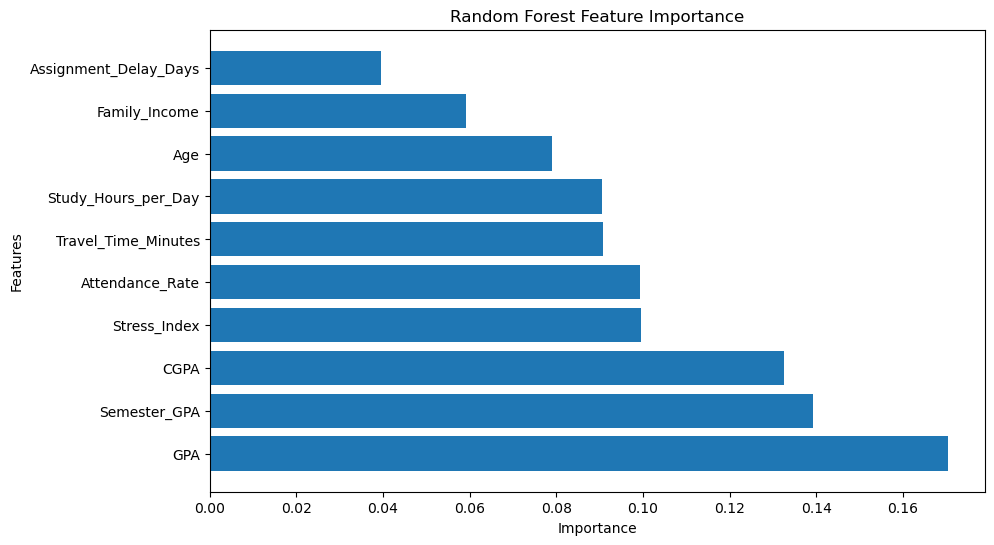

In [40]:
# Graphically representation

plt.figure(figsize=(10,6))

plt.barh(feature_importance["Feature"].astype(str),
         feature_importance["Importance"])

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()